# 🏦 Credit Card Underwriting — End-to-End ML Pipeline
**Dataset:** `cc_underwriting_5k_stratified.csv` | **Target:** `target_approved` (Yes / No)

---
### 📋 Pipeline Outline
| Step | Topic |
|------|-------|
| 1 | Setup & Imports |
| 2 | Load Data & Quick EDA |
| 3 | Missing Value Detection & Treatment |
| 4 | WoE (Weight of Evidence) & IV (Information Value) |
| 5 | Feature Engineering |
| 6 | Feature Selection (IV + Correlation) |
| 7 | Train / Test Split & Scaling |
| 8 | Random Forest — Training & Tuning |
| 9 | Model Evaluation (AUC, KS, Gini, SHAP) |
| 10 | Scorecard Calibration (optional) |


## Step 1 — Setup & Imports

In [1]:
# ── Install required packages ─────────────────────────────────────────────────
!pip install -q shap imbalanced-learn

# ── Core ──────────────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
FIGSIZE = (14, 5)

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── SHAP ─────────────────────────────────────────────────────────────────────
import shap

# ── Random seed ───────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## Step 2 — Load Data & Quick EDA

In [2]:
DATA_PATH = 'cc_underwriting_5k_stratified11.csv'   # ← update path if needed

df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (4480, 200)


,applicant_id,age,gender,generation,marital_status,dependents_count,education_level,employment_status,occupation_category,industry_sector,years_employed,state,zip_code_prefix,housing_status,years_at_current_address,us_citizen_status,military_status,annual_income,monthly_income,other_annual_income,total_household_income,monthly_rent_mortgage,monthly_car_payment,monthly_utilities,monthly_insurance,...,underwriting_model_score_v2,underwriting_model_score_v3,combined_risk_score,target_approved,target_credit_limit_assigned,phone_type,email_domain_type,credit_freeze_flag,opt_out_prescreened,banking_product_count,mobile_banking_user,avg_transaction_amount,num_transactions_last_30d,largest_single_purchase_ever,months_since_last_cc_application,self_reported_monthly_rent,bureau_pull_consent,application_completion_time_mins,prior_cc_with_this_bank,loyalty_program_member,credit_counseling_flag,income_growth_rate_yoy,num_address_changes_5yr,stated_purpose,marketing_segment
0,APP000011968,62,Female,Boomer+,Single,3,High School Diploma,Part-Time,Production,Real Estate,7,NC,14216,Live with Family,2.0000,Yes,NaN,32690.0000,2724.1700,0,33410.0000,29.0000,0,289.0000,418.0000,...,465,406,408,Yes,750,Mobile,Gmail,No,Yes,5,No,190.8500,25,5791.5900,120,29.0000,Hard Pull,28.8000,Yes,No,Yes,0.0416,1,Balance Transfer,Mass Affluent
1,APP000090069,69,Male,Boomer+,Single,0,Bachelor Degree,Full-Time,Education,Legal,0,UT,29446,Mortgage,1.6000,Yes,NaN,108000.0000,9000.0000,0,107000.0000,1638.0000,0,173.0000,186.0000,...,462,423,422,Yes,10000,Mobile,Gmail,No,No,0,Yes,55.4900,8,17282.3500,1,1638.0000,Hard Pull,12.0000,No,Yes,No,0.0807,0,Everyday Purchases,Mass Affluent
2,APP000088384,42,Female,Millennial,Married,1,Bachelor Degree,Full-Time,Management,Technology,6,NM,88043,Other,0.7000,Yes,NaN,13460.0000,1121.6700,2000,36460.0000,1546.0000,0,146.0000,455.0000,...,200,225,221,No,0,Mobile,Gmail,No,No,1,Yes,97.2000,21,148.9400,36,1546.0000,Hard Pull,8.0000,No,No,No,0.0534,0,Everyday Purchases,Emerging Affluent


Target distribution:
target_approved
Yes    2913
No     1567
Name: count, dtype: int64

Approval rate: 65.0%


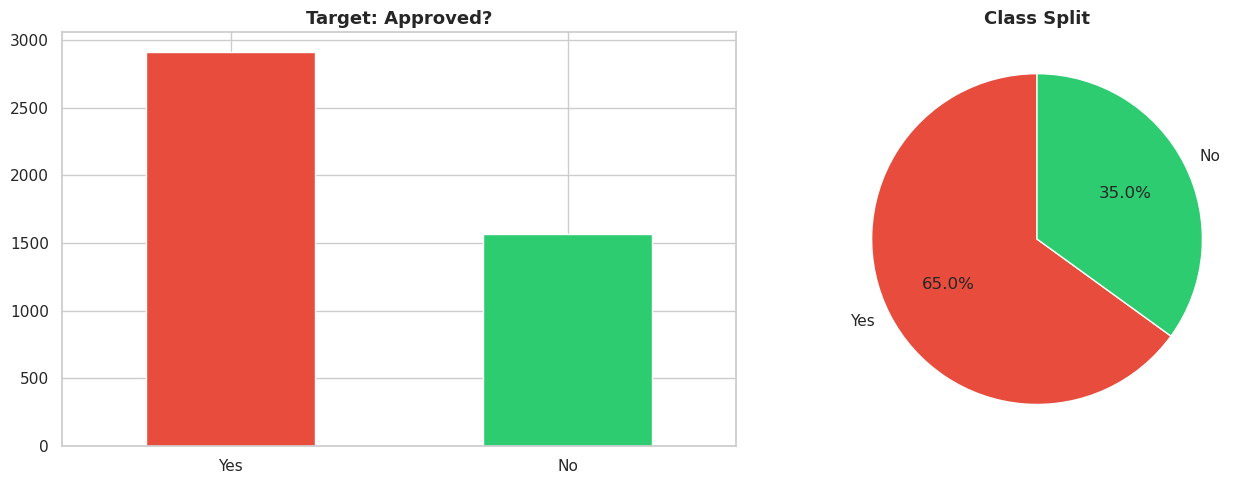

In [3]:
# ── Target distribution ───────────────────────────────────────────────────────
target_counts = df_raw['target_approved'].value_counts()
print('Target distribution:')
print(target_counts)
print(f'\nApproval rate: {target_counts["Yes"] / len(df_raw):.1%}')

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
target_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Target: Approved?', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Class Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# ── Column type summary ───────────────────────────────────────────────────────
numeric_cols = df_raw.select_dtypes(include='number').columns.tolist()
cat_cols     = df_raw.select_dtypes(include=['object', 'string']).columns.tolist()

# Remove ID and target from feature lists
IGNORE = ['applicant_id', 'target_approved', 'target_credit_limit_assigned']
numeric_cols = [c for c in numeric_cols if c not in IGNORE]
cat_cols     = [c for c in cat_cols     if c not in IGNORE]

print(f'Numeric features : {len(numeric_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Total feature candidates: {len(numeric_cols) + len(cat_cols)}')

Numeric features : 139
Categorical features: 58
Total feature candidates: 197


In [5]:
# ── Descriptive statistics for key numeric fields ────────────────────────────
KEY_NUM = ['age', 'annual_income', 'fico_score', 'debt_to_income_ratio',
           'credit_utilization_ratio', 'net_worth', 'requested_credit_limit',
           'fraud_risk_score', 'avg_bureau_score', 'monthly_disposable_income']

df_raw[KEY_NUM].describe().T.style.background_gradient(cmap='YlOrRd', axis=1)

,count,mean,std,min,25%,50%,75%,max
age,4480.000000,41.699330,12.652817,18.000000,33.000000,41.000000,50.000000,85.000000
annual_income,4480.000000,45545.274554,41447.857478,200.000000,18447.500000,35100.000000,59992.500000,500000.000000
fico_score,4480.000000,535.816518,69.655897,337.000000,487.000000,527.000000,578.000000,828.000000
debt_to_income_ratio,4480.000000,1.114532,0.649426,0.045500,0.531425,0.981900,1.979350,2.000000
credit_utilization_ratio,4480.000000,0.331018,0.177076,0.003800,0.190675,0.311600,0.454800,0.886300
net_worth,4480.000000,181218.723674,399256.570108,-1482495.580000,17545.865000,78285.300000,233308.327500,4867437.160000
requested_credit_limit,4480.000000,6218.638393,7271.411841,500.000000,2000.000000,4000.000000,7500.000000,50000.000000
fraud_risk_score,4480.000000,0.169508,0.104291,0.003000,0.088975,0.150950,0.228225,0.738900
avg_bureau_score,4480.000000,535.288170,70.165703,332.000000,486.000000,527.000000,577.000000,831.000000
monthly_disposable_income,4480.000000,808.513574,3607.335677,-6006.330000,-1500.040000,51.915000,2164.415000,38120.670000


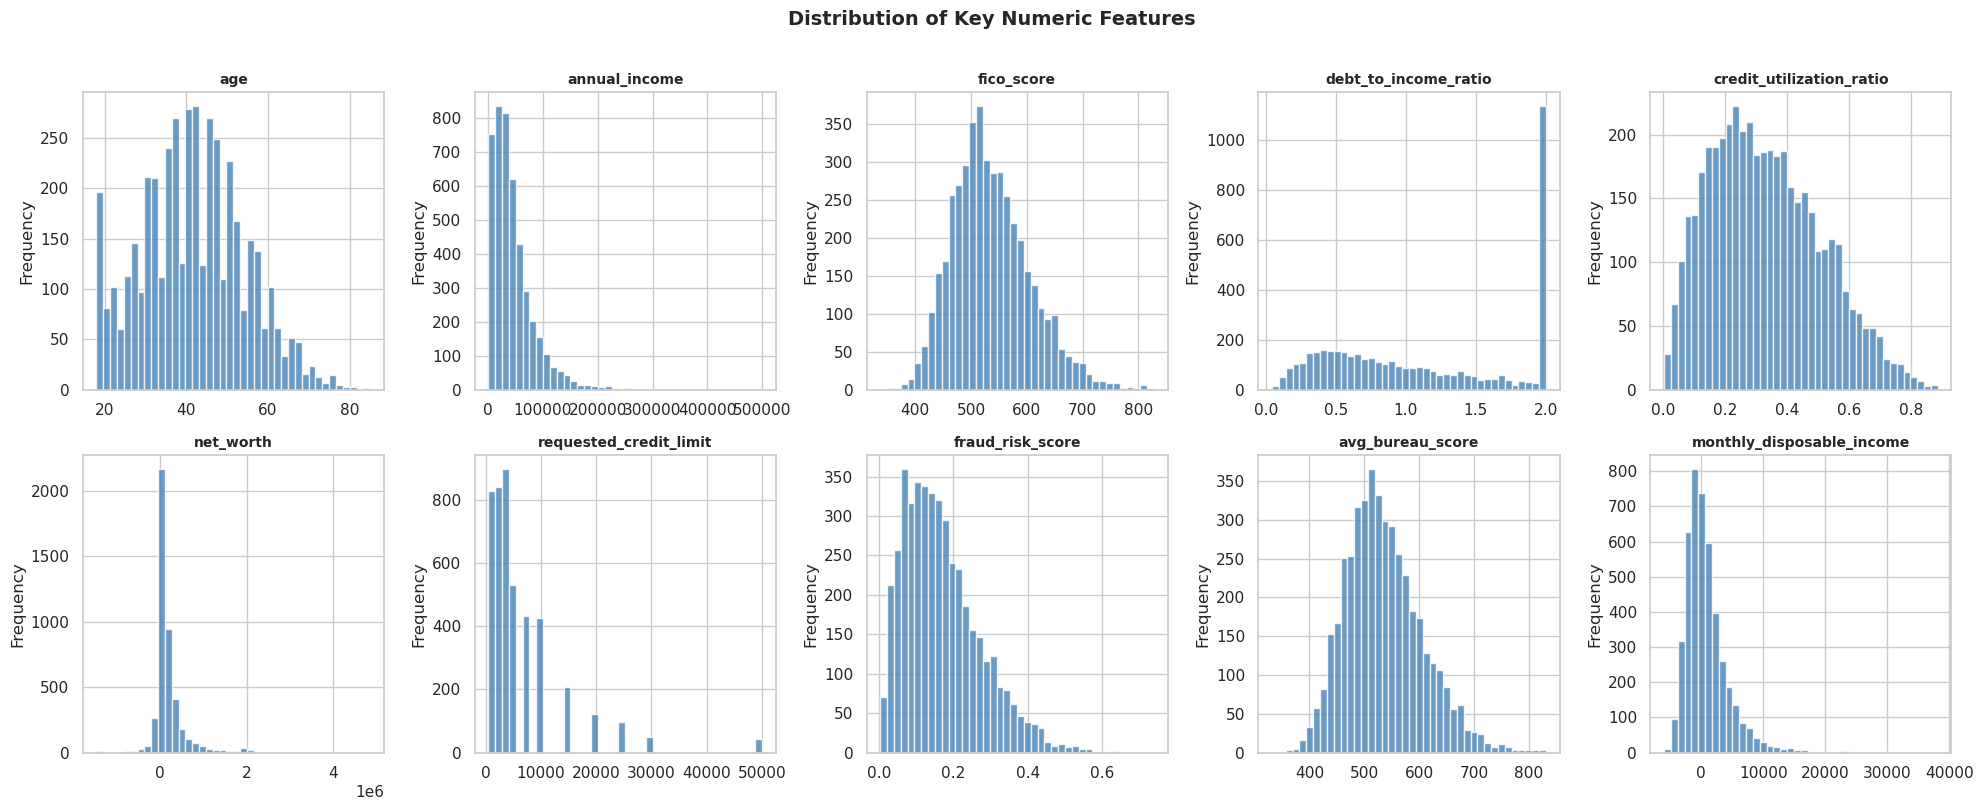

In [6]:
# ── Distribution plots for key numerics ──────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(KEY_NUM):
    df_raw[col].dropna().plot(kind='hist', bins=40, ax=axes[i],
                               color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Key Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 3 — Missing Value Detection & Treatment

In [7]:
# ── 3.1  Missing value audit ──────────────────────────────────────────────────
def missing_report(df):
    missing = df.isnull().sum()
    pct     = (missing / len(df)) * 100
    report  = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
    report  = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    return report

miss = missing_report(df_raw)
print(f'Columns with missing values: {len(miss)}')
miss

Columns with missing values: 3


,missing_count,missing_pct
military_status,3915,87.3884
promo_code_used,3161,70.5580
phone_type,242,5.4018


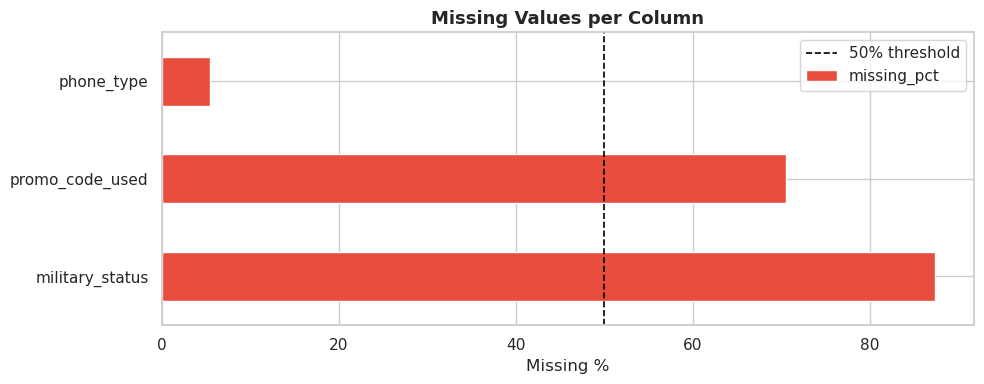

In [8]:
# ── 3.2  Visualise missingness ────────────────────────────────────────────────
if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    miss['missing_pct'].plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.axvline(x=50, color='black', linestyle='--', linewidth=1.2, label='50% threshold')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values per Column', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [9]:
# ── 3.3  Drop columns with > 50% missing ──────────────────────────────────────
HIGH_MISS_THRESH = 50.0
drop_high_miss = miss[miss['missing_pct'] > HIGH_MISS_THRESH].index.tolist()
print(f'Dropping {len(drop_high_miss)} high-missingness columns: {drop_high_miss}')

df = df_raw.drop(columns=drop_high_miss)

# Update column lists
numeric_cols = [c for c in numeric_cols if c in df.columns]
cat_cols     = [c for c in cat_cols     if c in df.columns]

Dropping 2 high-missingness columns: ['military_status', 'promo_code_used']


In [10]:
# ── 3.4  Impute remaining missing values ──────────────────────────────────────
#  Numeric  → median imputation (robust to skew)
#  Categorical → mode (most frequent)

# Numeric imputer
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  [NUMERIC]  {col:40s} → filled with median = {median_val:.3f}')

# Categorical imputer
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  [CATEGOR]  {col:40s} → filled with mode = "{mode_val}"')

print(f'\n✅ Remaining nulls: {df.isnull().sum().sum()}')

  [CATEGOR]  phone_type                               → filled with mode = "Mobile"

✅ Remaining nulls: 0


## Step 4 — WoE (Weight of Evidence) & IV (Information Value)

**WoE** transforms features into a log-odds scale aligned with the target.  
**IV** measures predictive power: IV < 0.02 = useless · 0.02-0.1 = weak · 0.1-0.3 = medium · > 0.3 = strong

$$\text{WoE}_i = \ln\left(\frac{\%\text{Events}_i}{\%\text{Non-Events}_i}\right) \qquad \text{IV} = \sum_i (\%E_i - \%NE_i) \times \text{WoE}_i$$

In [11]:
# ── 4.1  Encode target  (Yes=1 / No=0) ───────────────────────────────────────
df['target'] = (df['target_approved'] == 'Yes').astype(int)
print('Target encoding check:')
print(df['target'].value_counts())

Target encoding check:
target
1    2913
0    1567
Name: count, dtype: int64


In [12]:
# ── 4.2  Manual WoE / IV calculator (works for any column type) ──────────────
def compute_woe_iv(df, feature, target='target', bins=10, cat=False):
    """
    Returns a WoE table and scalar IV for a single feature.
    Uses quantile binning for numeric, raw values for categorical.
    The returned table always has the feature name as the first column.
    """
    total_events     = df[target].sum()
    total_non_events = len(df) - total_events

    if cat:
        groups = df.groupby(feature)[target]
    else:
        try:
            df['_bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
        except Exception:
            df['_bin'] = pd.cut(df[feature], bins=bins)
        groups = df.groupby('_bin')[target]

    tbl = groups.agg(['sum', 'count'])

    # Flatten MultiIndex columns if present
    if isinstance(tbl.columns, pd.MultiIndex):
        tbl.columns = ['_'.join(str(c) for c in col).strip('_') for col in tbl.columns]

    # Normalise column names to 'events' and 'total'
    col_map = {}
    for c in tbl.columns:
        cl = c.lower()
        if 'sum' in cl:
            col_map[c] = 'events'
        elif 'count' in cl:
            col_map[c] = 'total'
    tbl = tbl.rename(columns=col_map)

    tbl['non_events'] = tbl['total'] - tbl['events']

    tbl['pct_events']     = tbl['events']     / total_events
    tbl['pct_non_events'] = tbl['non_events'] / total_non_events

    # Smooth zeros to avoid log(0)
    eps = 1e-6
    tbl['woe'] = np.log((tbl['pct_events'] + eps) / (tbl['pct_non_events'] + eps))
    tbl['iv']  = (tbl['pct_events'] - tbl['pct_non_events']) * tbl['woe']

    iv_total = tbl['iv'].sum()
    result = tbl.reset_index()

    # Rename the bin / index column to the feature name
    if result.columns[0] != feature:
        result = result.rename(columns={result.columns[0]: feature})

    return result, iv_total


def iv_label(iv):
    if iv < 0.02:  return 'Useless'
    if iv < 0.10:  return 'Weak'
    if iv < 0.30:  return 'Medium'
    return 'Strong'

print('Helper functions defined ✅')

Helper functions defined ✅


In [13]:
# ── 4.3  Compute IV for all features ─────────────────────────────────────────
# Select a representative subset for speed; remove very high-cardinality cats
MAX_CAT_CARDINALITY = 30
selected_cats = [c for c in cat_cols
                 if df[c].nunique() <= MAX_CAT_CARDINALITY]

# Numeric subset — use key columns + all available
selected_nums = numeric_cols[:60]   # cap at 60 for speed in this cell

iv_results = []

for col in selected_nums:
    try:
        _, iv = compute_woe_iv(df.copy(), col, cat=False)
        iv_results.append({'feature': col, 'iv': iv, 'type': 'numeric'})
    except Exception:
        pass

for col in selected_cats:
    try:
        _, iv = compute_woe_iv(df.copy(), col, cat=True)
        iv_results.append({'feature': col, 'iv': iv, 'type': 'categorical'})
    except Exception:
        pass

iv_df = (pd.DataFrame(iv_results)
           .sort_values('iv', ascending=False)
           .reset_index(drop=True))
iv_df['strength'] = iv_df['iv'].apply(iv_label)

print(f'IV computed for {len(iv_df)} features')
iv_df.head(20)

IV computed for 114 features


,feature,iv,type,strength
0,debt_to_income_ratio,6.8295,numeric,Strong
1,experian_score,6.0202,numeric,Strong
2,fico_score,5.5137,numeric,Strong
3,avg_bureau_score,5.3466,numeric,Strong
4,equifax_score,4.9440,numeric,Strong
5,transunion_score,4.9094,numeric,Strong
6,monthly_income,3.6952,numeric,Strong
7,annual_income,3.6952,numeric,Strong
8,avg_monthly_deposits,3.6496,numeric,Strong
9,avg_monthly_withdrawals,3.5052,numeric,Strong


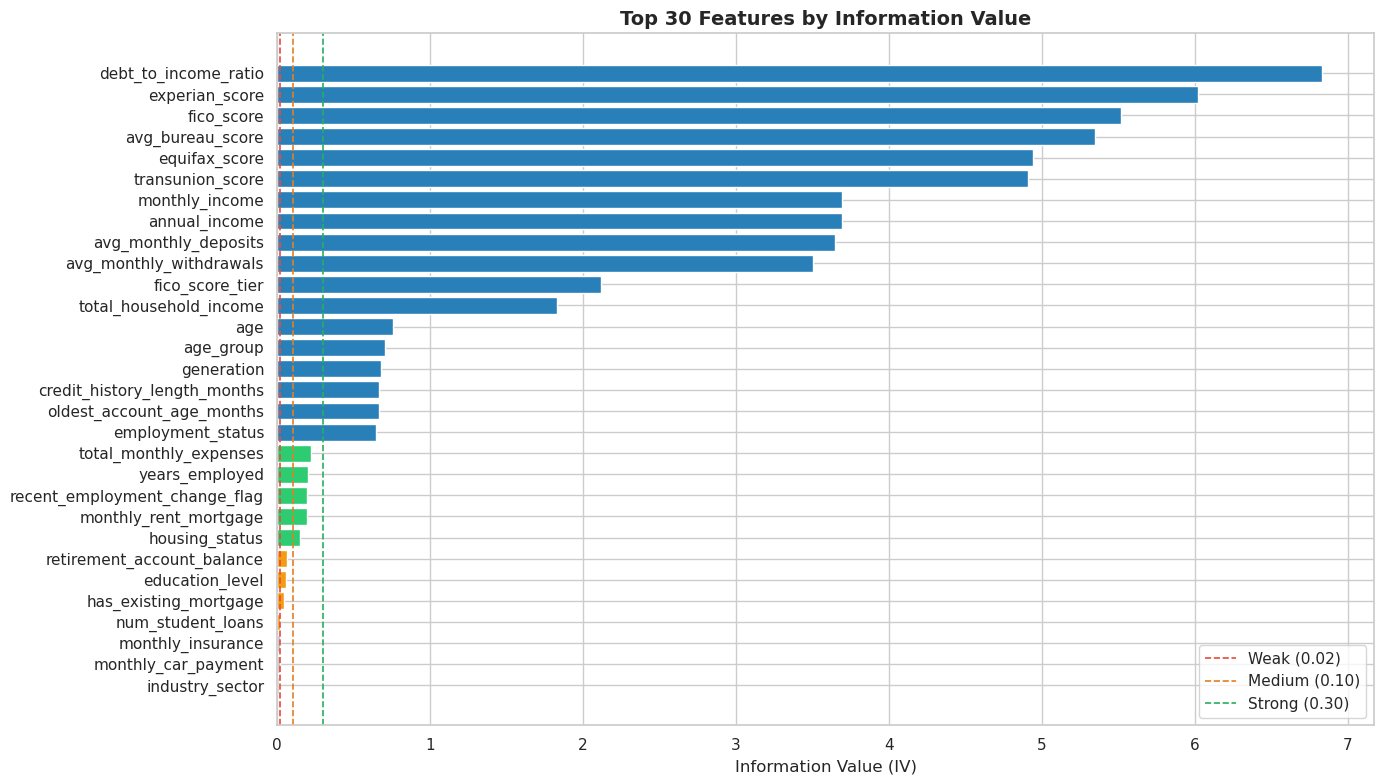

In [14]:
# ── 4.4  IV bar chart ─────────────────────────────────────────────────────────
TOP_N = 30
top_iv = iv_df.head(TOP_N)

color_map = {'Useless': '#bdc3c7', 'Weak': '#f39c12', 'Medium': '#2ecc71', 'Strong': '#2980b9'}
colors    = top_iv['strength'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top_iv['feature'][::-1], top_iv['iv'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=0.02, color='#e74c3c', linestyle='--', linewidth=1.2, label='Weak (0.02)')
ax.axvline(x=0.10, color='#e67e22', linestyle='--', linewidth=1.2, label='Medium (0.10)')
ax.axvline(x=0.30, color='#27ae60', linestyle='--', linewidth=1.2, label='Strong (0.30)')
ax.set_xlabel('Information Value (IV)', fontsize=12)
ax.set_title(f'Top {TOP_N} Features by Information Value', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [15]:
# ── 4.5  WoE table for a single key feature (example: fico_score) ───────────
woe_tbl, iv_val = compute_woe_iv(df.copy(), 'fico_score', cat=False, bins=10)
print(f'IV for fico_score: {iv_val:.4f}  ({iv_label(iv_val)})')
woe_tbl[['fico_score', 'events', 'non_events', 'pct_events', 'pct_non_events', 'woe', 'iv']]

IV for fico_score: 5.5137  (Strong)


,fico_score,events,non_events,pct_events,pct_non_events,woe,iv
0,"(336.999, 453.0]",8,450,0.0027,0.2872,-4.6495,1.3224
1,"(453.0, 478.0]",77,382,0.0264,0.2438,-2.2216,0.4829
2,"(478.0, 496.0]",142,307,0.0487,0.1959,-1.3910,0.2047
3,"(496.0, 511.0]",236,209,0.0810,0.1334,-0.4985,0.0261
4,"(511.0, 527.0]",310,128,0.1064,0.0817,0.2645,0.0065
5,"(527.0, 546.0]",396,56,0.1359,0.0357,1.3360,0.1339
6,"(546.0, 566.0]",416,26,0.1428,0.0166,2.1525,0.2717
7,"(566.0, 591.0]",445,7,0.1528,0.0045,3.5319,0.5238
8,"(591.0, 630.1]",435,2,0.1493,0.0013,4.7614,0.7049
9,"(630.1, 828.0]",448,0,0.1538,0.0000,11.9434,1.8368


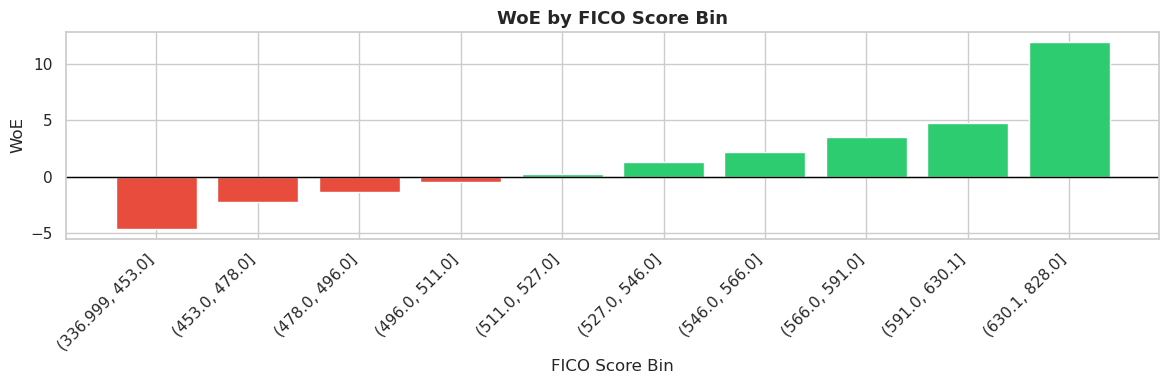

In [16]:
# ── 4.6  WoE plot for fico_score ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
x_labels = [str(b) for b in woe_tbl['fico_score']]
ax.bar(x_labels, woe_tbl['woe'],
       color=['#2ecc71' if w > 0 else '#e74c3c' for w in woe_tbl['woe']],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('FICO Score Bin')
ax.set_ylabel('WoE')
ax.set_title('WoE by FICO Score Bin', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 5 — Feature Engineering

In [17]:
# ── 5.1  Ratio / interaction features ────────────────────────────────────────
df_fe = df.copy()

eps = 1e-6   # avoid division by zero

# --- Financial stress ratios
df_fe['income_to_limit_ratio']    = df_fe['annual_income'] / (df_fe['requested_credit_limit'] + eps)
df_fe['expenses_to_income_ratio'] = df_fe['total_monthly_expenses'] / (df_fe['monthly_income'] + eps)
df_fe['savings_to_income_ratio']  = df_fe['savings_account_balance'] / (df_fe['annual_income'] + eps)
df_fe['assets_to_liabilities']    = df_fe['total_assets'] / (df_fe['total_liabilities'] + eps)

# --- Credit health features
df_fe['bureau_score_mean']        = df_fe[['fico_score','equifax_score','experian_score','transunion_score']].mean(axis=1)
df_fe['bureau_score_std']         = df_fe[['fico_score','equifax_score','experian_score','transunion_score']].std(axis=1)
df_fe['credit_history_yrs']       = df_fe['credit_history_length_months'] / 12
df_fe['utilization_x_inquiries']  = df_fe['credit_utilization_ratio'] * df_fe['hard_inquiries_last_12mo']
df_fe['derogatory_x_dti']         = df_fe['derogatory_marks_count'] * df_fe['debt_to_income_ratio']

# --- Income & employment
df_fe['monthly_net_income']       = df_fe['monthly_income'] - df_fe['total_monthly_expenses']
df_fe['income_per_dependent']     = df_fe['annual_income'] / (df_fe['dependents_count'] + 1)
df_fe['income_yrs_employed']      = df_fe['annual_income'] * df_fe['years_employed']

# --- Risk flags aggregated
risk_flags = ['prior_default_flag','prior_bankruptcy_flag','high_risk_industry_flag',
              'recent_address_change_flag','recent_employment_change_flag','multiple_applications_flag',
              'thin_file_flag','no_hit_flag']
# Convert Yes/No to 1/0
for f in risk_flags:
    if f in df_fe.columns:
        df_fe[f + '_enc'] = (df_fe[f] == 'Yes').astype(int)

risk_enc_cols = [f + '_enc' for f in risk_flags if f + '_enc' in df_fe.columns]
df_fe['total_risk_flags']        = df_fe[risk_enc_cols].sum(axis=1)

# --- Age-based
df_fe['age_squared']              = df_fe['age'] ** 2
df_fe['age_x_fico']               = df_fe['age'] * df_fe['fico_score']

NEW_FEATURES = [
    'income_to_limit_ratio','expenses_to_income_ratio','savings_to_income_ratio',
    'assets_to_liabilities','bureau_score_mean','bureau_score_std','credit_history_yrs',
    'utilization_x_inquiries','derogatory_x_dti','monthly_net_income','income_per_dependent',
    'income_yrs_employed','total_risk_flags','age_squared','age_x_fico'
]

print(f'✅ Created {len(NEW_FEATURES)} engineered features')
df_fe[NEW_FEATURES].describe().T[['mean','std','min','max']]

✅ Created 15 engineered features


,mean,std,min,max
income_to_limit_ratio,18.1366,30.2911,0.0174,614.4800
expenses_to_income_ratio,2.5137,6.0800,0.0455,136.4501
savings_to_income_ratio,0.3468,1.7194,0.0003,55.1051
assets_to_liabilities,35.7351,237.0981,0.0117,11791.7009
bureau_score_mean,535.4207,69.9448,333.2500,828.2500
bureau_score_std,11.7624,5.3990,0.5000,36.9594
credit_history_yrs,14.2743,8.0247,0.0000,47.7500
utilization_x_inquiries,0.4618,0.5049,0.0000,4.7110
derogatory_x_dti,0.4887,1.2941,0.0000,10.0000
monthly_net_income,808.5136,3607.3357,-6006.3300,38120.6700


In [18]:
# ── 5.2  Log-transform skewed numerics ────────────────────────────────────────
SKEWED = ['annual_income', 'monthly_income', 'net_worth', 'total_assets',
          'savings_account_balance', 'requested_credit_limit', 'total_liabilities']

for col in SKEWED:
    if col in df_fe.columns:
        df_fe[col + '_log'] = np.log1p(np.clip(df_fe[col], 0, None))

LOG_FEATURES = [c + '_log' for c in SKEWED if c in df_fe.columns]
print(f'✅ Log-transformed {len(LOG_FEATURES)} skewed features')

✅ Log-transformed 7 skewed features


In [19]:
# ── 5.3  Encode categorical features (Label Encoding) ────────────────────────
# Select categoricals with manageable cardinality
cat_for_model = [c for c in cat_cols if df_fe[c].nunique() <= 30]

le = LabelEncoder()
for col in cat_for_model:
    df_fe[col + '_enc'] = le.fit_transform(df_fe[col].astype(str))

CAT_ENC_FEATURES = [c + '_enc' for c in cat_for_model]
print(f'✅ Label-encoded {len(CAT_ENC_FEATURES)} categorical features')

✅ Label-encoded 54 categorical features


## Step 6 — Feature Selection (IV + Correlation Filter)

In [20]:
# ── 6.1  Build full feature matrix ───────────────────────────────────────────
ALL_FEATURES = (numeric_cols
                + NEW_FEATURES
                + LOG_FEATURES
                + CAT_ENC_FEATURES)

# Keep only columns present in df_fe
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_fe.columns]
# Remove duplicates preserving order
seen = set()
ALL_FEATURES = [f for f in ALL_FEATURES if not (f in seen or seen.add(f))]

print(f'Total candidate features before selection: {len(ALL_FEATURES)}')

Total candidate features before selection: 215


In [21]:
# ── 6.2  IV filter — keep Medium / Strong only (IV >= 0.02) ───────────────────
MIN_IV = 0.02
iv_selected = iv_df[iv_df['iv'] >= MIN_IV]['feature'].tolist()

# Keep features that either passed IV or are engineered (not measured in IV step)
engineered = NEW_FEATURES + LOG_FEATURES
FEATURES_AFTER_IV = [f for f in ALL_FEATURES if f in iv_selected or f in engineered]
print(f'Features after IV filter: {len(FEATURES_AFTER_IV)}')

Features after IV filter: 41


In [22]:
# ── 6.3  Correlation filter — drop one of any pair with |r| > 0.95 ───────────
X_raw = df_fe[FEATURES_AFTER_IV].copy()

corr_matrix = X_raw.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

CORR_THRESH = 0.95
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > CORR_THRESH)]
print(f'Dropping {len(to_drop_corr)} highly correlated features: {to_drop_corr[:10]}...')

FINAL_FEATURES = [f for f in FEATURES_AFTER_IV if f not in to_drop_corr]
print(f'\nFinal feature count: {len(FINAL_FEATURES)}')

Dropping 14 highly correlated features: ['monthly_income', 'total_household_income', 'equifax_score', 'experian_score', 'transunion_score', 'avg_bureau_score', 'oldest_account_age_months', 'avg_monthly_deposits', 'avg_monthly_withdrawals', 'bureau_score_mean']...

Final feature count: 27


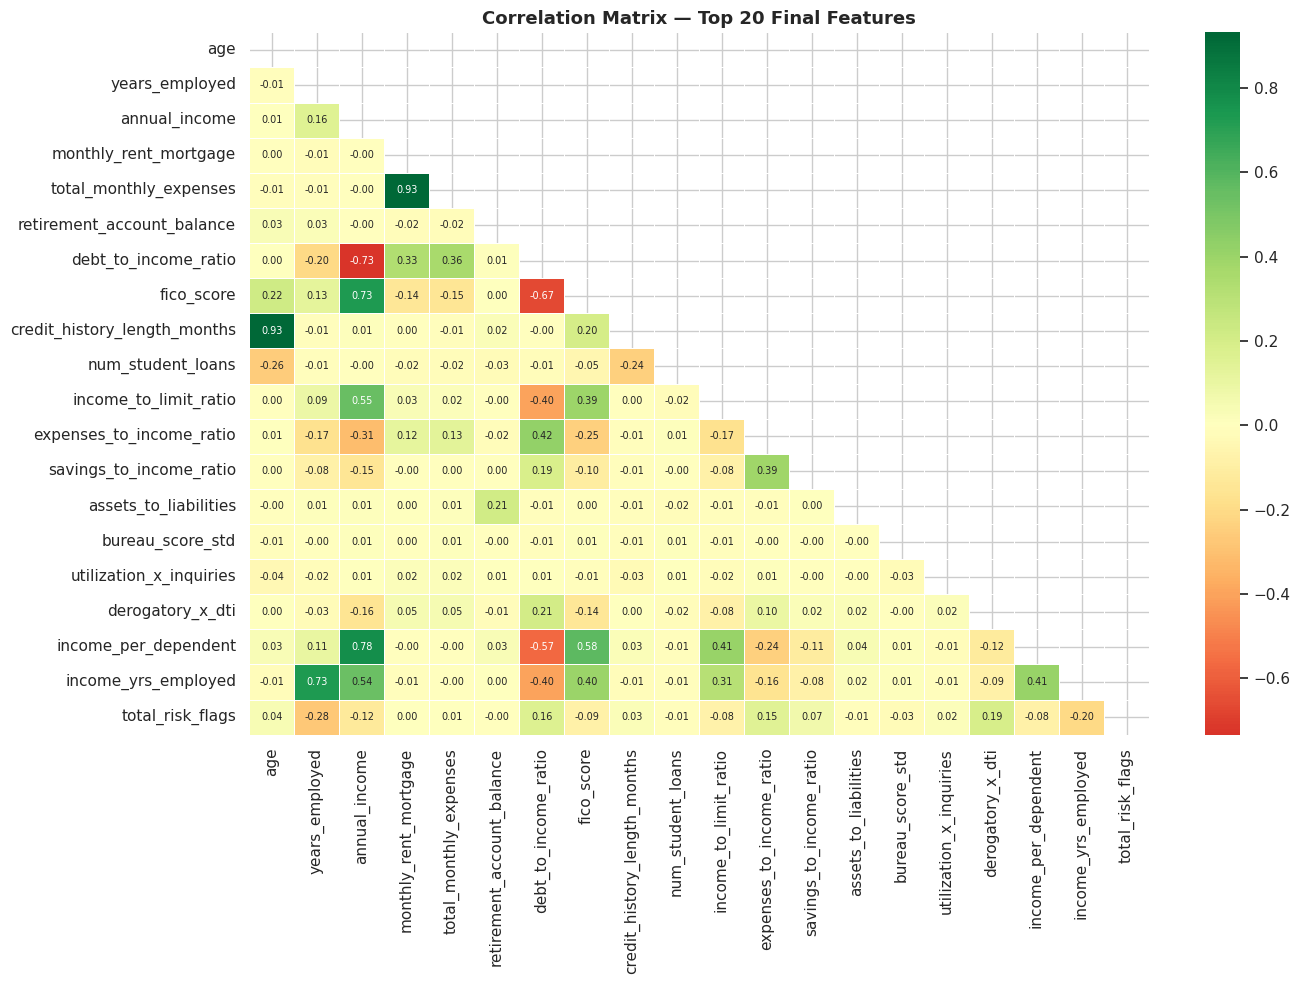

In [23]:
# ── 6.4  Correlation heatmap for top 20 final features ───────────────────────
top20 = FINAL_FEATURES[:20]
fig, ax = plt.subplots(figsize=(14, 10))
corr20 = df_fe[top20].corr()
mask   = np.triu(np.ones_like(corr20, dtype=bool))
sns.heatmap(corr20, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Top 20 Final Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 — Train / Test Split & Scaling

In [24]:
# ── 7.1  Prepare X and y ─────────────────────────────────────────────────────
X = df_fe[FINAL_FEATURES].copy().fillna(0)   # final safety fill
y = df_fe['target'].copy()

print(f'X shape: {X.shape}')
print(f'y value counts:\n{y.value_counts()}')

X shape: (4480, 27)
y value counts:
target
1    2913
0    1567
Name: count, dtype: int64


In [25]:
# ── 7.2  Stratified split 80/20 ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train size : {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')
print(f'Train target rate: {y_train.mean():.3f}  |  Test target rate: {y_test.mean():.3f}')

Train size : 3584  |  Test size: 896
Train target rate: 0.650  |  Test target rate: 0.651


In [26]:
# ── 7.3  SMOTE — address class imbalance on TRAIN only ───────────────────────
print(f'Before SMOTE — class distribution:\n{pd.Series(y_train).value_counts()}')

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE — class distribution:\n{pd.Series(y_train_sm).value_counts()}')

Before SMOTE — class distribution:
target
1    2330
0    1254
Name: count, dtype: int64

After SMOTE — class distribution:
target
1    2330
0    2330
Name: count, dtype: int64


In [27]:
# ── 7.4  Scale features (StandardScaler) ─────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

# Keep DataFrame for SHAP plots
X_train_sc_df = pd.DataFrame(X_train_sc, columns=FINAL_FEATURES)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=FINAL_FEATURES)

print('✅ Scaling complete')

✅ Scaling complete


## Step 8 — Random Forest Training & Hyperparameter Tuning

In [34]:
# ── 8.1  Baseline Random Forest ──────────────────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)
rf_base.fit(X_train_sc, y_train_sm)

# Cross-validation AUC on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf_base, X_train_sc, y_train_sm,
                             scoring='roc_auc', cv=cv, n_jobs=-1)
print(f'Baseline CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Baseline CV AUC: 0.9979 ± 0.0010


In [35]:
# ── 8.2  RandomizedSearchCV hyperparameter tuning ────────────────────────────
param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5],
    'class_weight'     : ['balanced', None]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,              # increase for production
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    random_state=SEED,
    verbose=1,
    n_jobs=-1
)
rf_tuned.fit(X_train_sc, y_train_sm)

print(f'\n✅ Best params: {rf_tuned.best_params_}')
print(f'   Best CV AUC : {rf_tuned.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'class_weight': None}
   Best CV AUC : 0.9978


In [30]:
# ── 8.3  Use best estimator ────────────────────────────────────────────────────
best_rf = rf_tuned.best_estimator_
print(best_rf)

RandomForestClassifier(max_depth=20, max_features=0.5, min_samples_split=5,
                       n_estimators=500, n_jobs=-1, random_state=42)


## Step 9 — Model Evaluation

In [31]:
# ── 9.1  Predictions ──────────────────────────────────────────────────────────
y_pred       = best_rf.predict(X_test_sc)
y_pred_proba = best_rf.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Declined', 'Approved']))

              precision    recall  f1-score   support

    Declined       0.92      0.98      0.95       313
    Approved       0.99      0.96      0.97       583

    accuracy                           0.96       896
   macro avg       0.96      0.97      0.96       896
weighted avg       0.97      0.96      0.96       896



In [32]:
# ── 9.2  AUC / ROC curve ──────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_pred_proba)
gini = 2 * auc - 1

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# KS statistic
ks = max(tpr - fpr)
ks_idx = np.argmax(tpr - fpr)

print(f'AUC  : {auc:.4f}')
print(f'Gini : {gini:.4f}')
print(f'KS   : {ks:.4f}  (threshold = {thresholds[ks_idx]:.3f})')

AUC  : 0.9964
Gini : 0.9929
KS   : 0.9450  (threshold = 0.470)


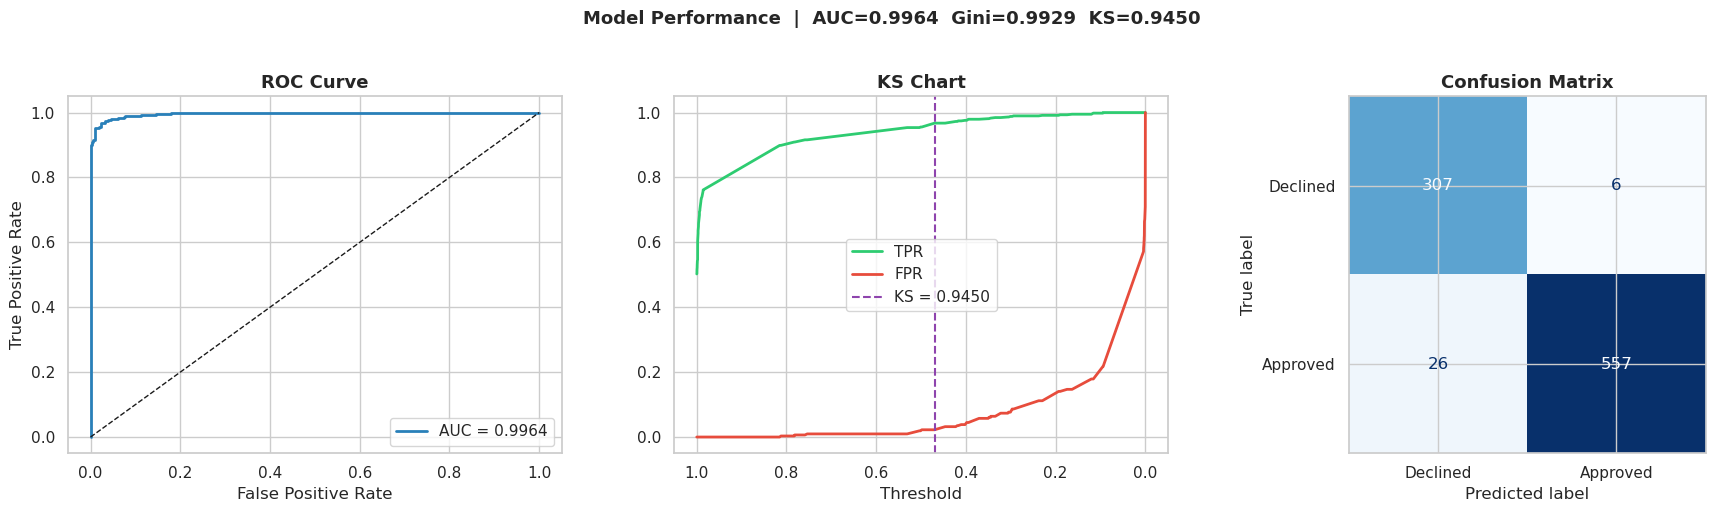

In [39]:
# ── 9.3  ROC + KS plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC Curve
axes[0].plot(fpr, tpr, color='#2980b9', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend()

# --- KS Chart
n = min(len(thresholds), len(tpr))
th_plot  = thresholds[:n]
tpr_plot = tpr[:n]
fpr_plot = fpr[:n]

axes[1].plot(th_plot, tpr_plot, label='TPR', color='#2ecc71', lw=2)
axes[1].plot(th_plot, fpr_plot, label='FPR', color='#e74c3c', lw=2)
axes[1].axvline(x=thresholds[ks_idx], color='#8e44ad', linestyle='--',
                label=f'KS = {ks:.4f}')
axes[1].set_xlabel('Threshold')
axes[1].set_title('KS Chart', fontsize=13, fontweight='bold')
axes[1].invert_xaxis()
axes[1].legend()

# --- Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Declined', 'Approved'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle(f'Model Performance  |  AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

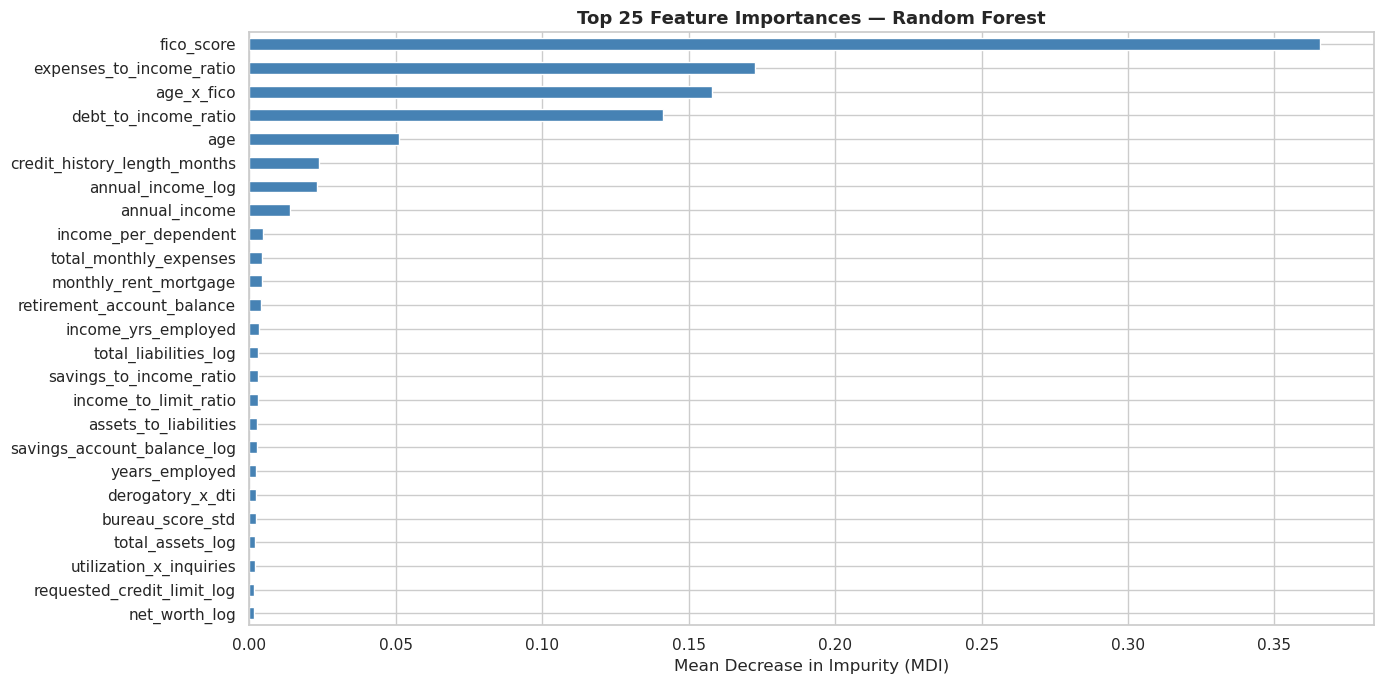

In [40]:
# ── 9.4  Feature Importance (MDI) ────────────────────────────────────────────
feat_imp = pd.Series(best_rf.feature_importances_, index=FINAL_FEATURES)\
             .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
feat_imp.head(25).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.set_title('Top 25 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

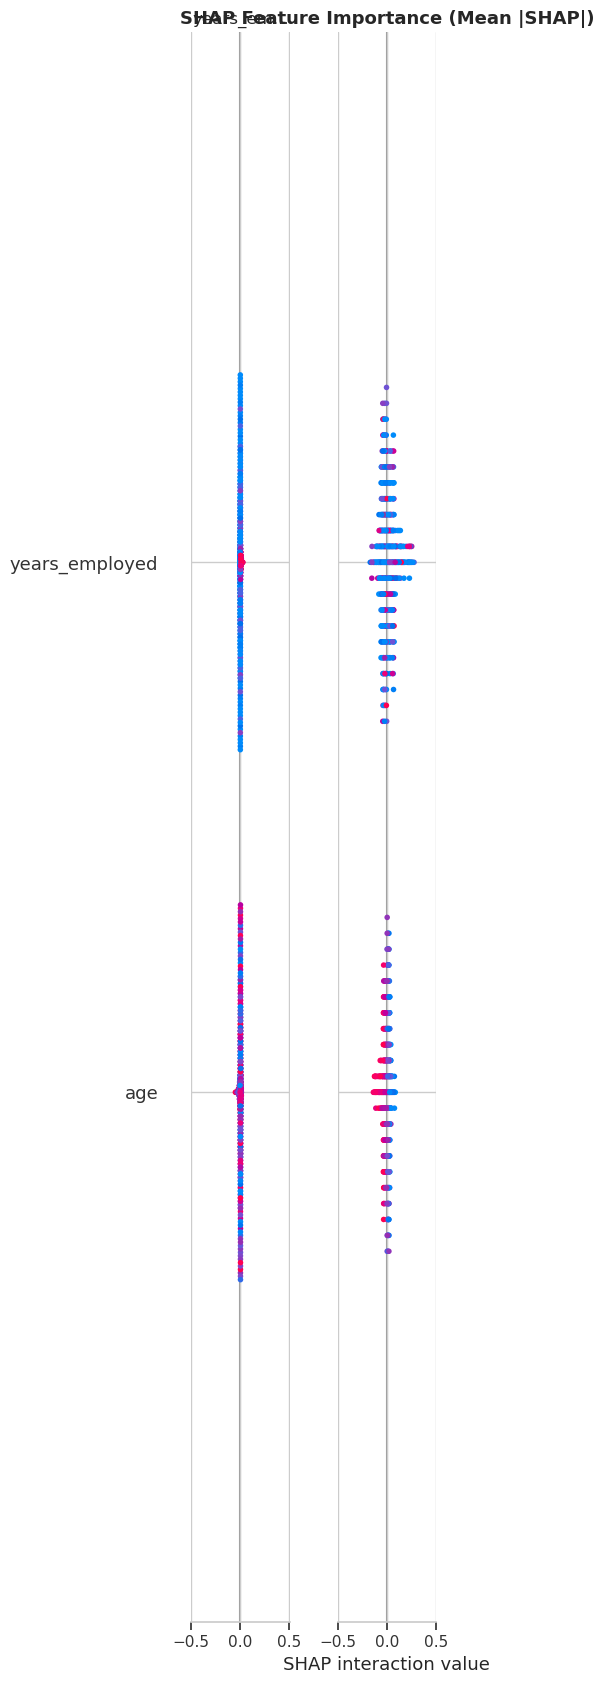

In [41]:
# ── 9.5  SHAP Explanation ─────────────────────────────────────────────────────
# Use a sample for speed
SHAP_SAMPLE = min(500, len(X_test_sc_df))
X_shap = X_test_sc_df.sample(SHAP_SAMPLE, random_state=SEED)

explainer    = shap.TreeExplainer(best_rf)
shap_values  = explainer.shap_values(X_shap)

# For binary classification: shap_values is a list [class0, class1]
shap_vals_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals_pos, X_shap, plot_type='bar',
                  max_display=20, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

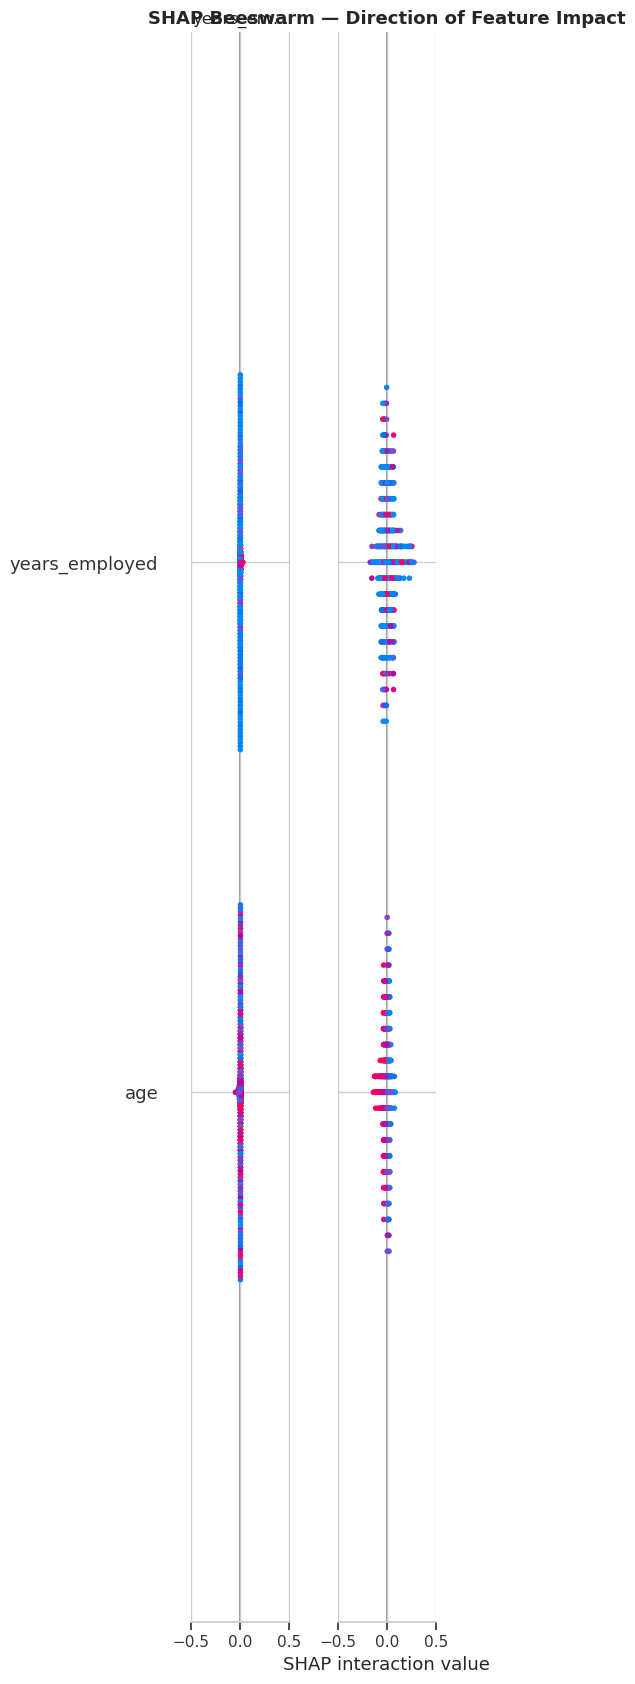

In [42]:
# ── 9.6  SHAP Beeswarm — direction of impact ──────────────────────────────────
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals_pos, X_shap, max_display=20, show=False)
plt.title('SHAP Beeswarm — Direction of Feature Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

shap_vals_pos type: <class 'numpy.ndarray'>, shape: (500, 27, 2)
expected_value: [0.50013734 0.49986266]


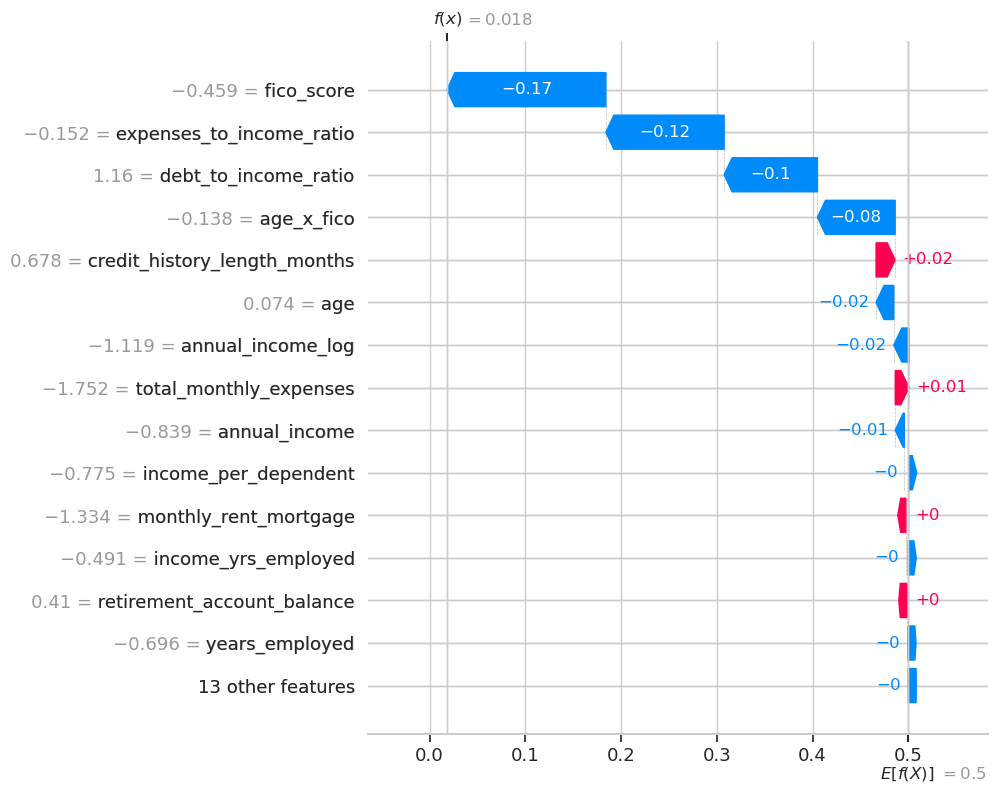

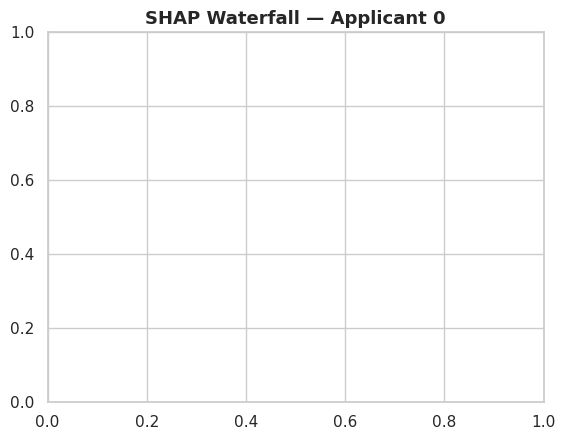

In [45]:
# ── 9.7  SHAP Waterfall — single applicant explanation ────────────────────────
idx = 0

# Debug: check actual shape
print(f'shap_vals_pos type: {type(shap_vals_pos)}, shape: {np.array(shap_vals_pos).shape}')
print(f'expected_value: {explainer.expected_value}')

# For RF binary classification, shap_values is list of 2 arrays each (n_samples, n_features)
# OR a single array of shape (n_samples, n_features, 2)
sv_arr = np.array(shap_vals_pos)

if sv_arr.ndim == 3:
    # shape (n_samples, n_features, n_classes) — pick class 1
    single = sv_arr[idx, :, 1]
elif sv_arr.ndim == 2 and sv_arr.shape[0] == len(X_shap):
    # shape (n_samples, n_features) — already class-specific
    single = sv_arr[idx]
else:
    # shape (n_features, 2) — this IS one sample, pick class 1
    single = sv_arr[:, 1]

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

shap.waterfall_plot(
    shap.Explanation(
        values        = single,
        base_values   = float(base_val),
        data          = X_shap.iloc[idx].values,
        feature_names = FINAL_FEATURES
    ),
    max_display=15
)
plt.title(f'SHAP Waterfall — Applicant {idx}', fontsize=13, fontweight='bold')
plt.show()

## Step 10 — Probability Score Distribution & Scorecard Calibration

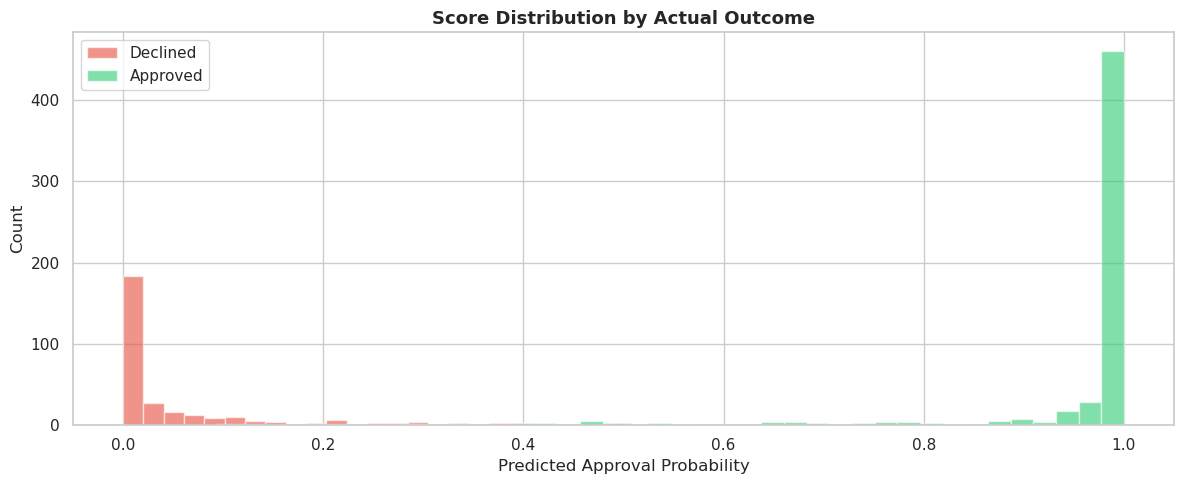

In [46]:
# ── 10.1  Score distribution by actual class ──────────────────────────────────
score_df = pd.DataFrame({'prob': y_pred_proba, 'actual': y_test.values})

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in [(0, '#e74c3c'), (1, '#2ecc71')]:
    subset = score_df[score_df['actual'] == label]['prob']
    ax.hist(subset, bins=40, alpha=0.6, color=color, edgecolor='white',
            label='Declined' if label==0 else 'Approved')
ax.set_xlabel('Predicted Approval Probability')
ax.set_ylabel('Count')
ax.set_title('Score Distribution by Actual Outcome', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
# ── 10.2  Scorecard-style banding ─────────────────────────────────────────────
# Map probability → score (higher score = lower risk, like a FICO style)
def prob_to_score(p, base=600, pdo=50, base_odds=1.0):
    """Convert probability to scorecard points (logistic scaling)."""
    odds = (1 - p) / (p + 1e-8)  # odds of non-event (good credit)
    factor = pdo / np.log(2)
    offset = base - factor * np.log(base_odds)
    return offset + factor * np.log(odds)

score_df['score'] = prob_to_score(score_df['prob'])

# Define risk bands
bins   = [0, 500, 560, 620, 680, 740, 850]
labels = ['Very High Risk', 'High Risk', 'Medium Risk', 'Low Risk', 'Very Low Risk', 'Excellent']
score_df['risk_band'] = pd.cut(score_df['score'], bins=bins, labels=labels, right=True)

band_summary = (score_df
    .groupby('risk_band', observed=True)
    .agg(
        count    = ('prob',   'count'),
        approved = ('actual', 'sum'),
        avg_score= ('score',  'mean')
    )
    .assign(approval_rate = lambda x: x['approved'] / x['count'])
)
print('Scorecard Risk Band Summary:')
band_summary

Scorecard Risk Band Summary:


,count,approved,avg_score,approval_rate
risk_band,,,,
Very High Risk,232,231,253.3698,0.9957
High Risk,26,24,527.0899,0.9231
Medium Risk,25,18,596.8079,0.7200
Low Risk,33,11,647.1030,0.3333
Very Low Risk,24,3,705.8919,0.1250
Excellent,59,3,787.0305,0.0508


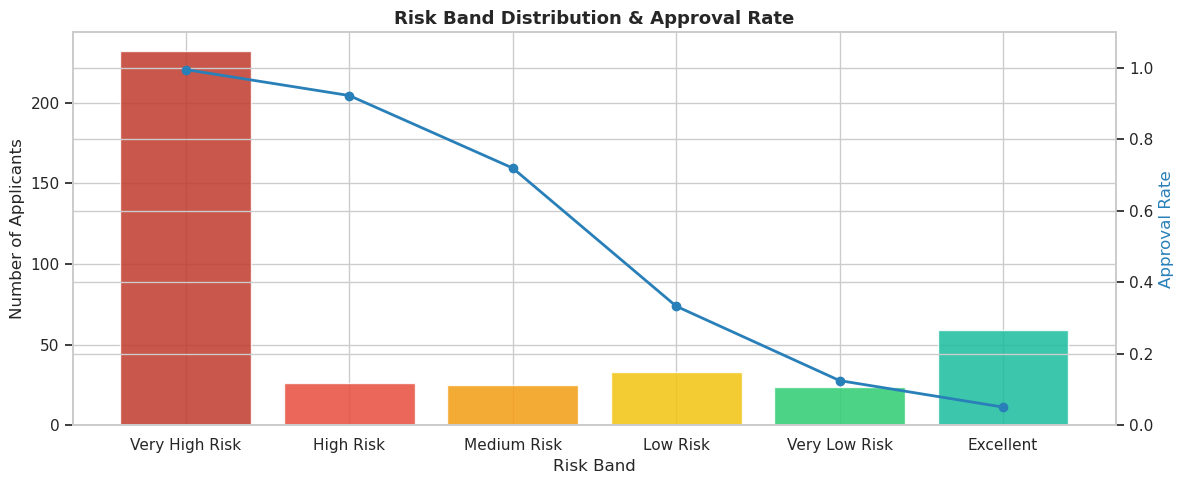

In [48]:
# ── 10.3  Risk band chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors_band = ['#c0392b','#e74c3c','#f39c12','#f1c40f','#2ecc71','#1abc9c']

bars = ax.bar(band_summary.index.astype(str), band_summary['count'],
              color=colors_band[:len(band_summary)], edgecolor='white', alpha=0.85)

ax2 = ax.twinx()
ax2.plot(band_summary.index.astype(str), band_summary['approval_rate'],
         color='#2980b9', marker='o', lw=2, label='Approval Rate')
ax2.set_ylabel('Approval Rate', color='#2980b9')
ax2.set_ylim(0, 1.1)

ax.set_xlabel('Risk Band')
ax.set_ylabel('Number of Applicants')
ax.set_title('Risk Band Distribution & Approval Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
# ── 10.4  Final summary ────────────────────────────────────────────────────────
print('=' * 60)
print('        CREDIT CARD UNDERWRITING MODEL — FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset shape       : {df_raw.shape}')
print(f'  Final features used : {len(FINAL_FEATURES)}')
print(f'  Train / Test split  : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'  SMOTE applied       : Yes (train only)')
print(f'  Model               : Random Forest (tuned)')
print(f'  Best params         : {rf_tuned.best_params_}')
print(f'  AUC (test)          : {auc:.4f}')
print(f'  Gini (test)         : {gini:.4f}')
print(f'  KS   (test)         : {ks:.4f}')
print('=' * 60)

        CREDIT CARD UNDERWRITING MODEL — FINAL SUMMARY
  Dataset shape       : (4480, 200)
  Final features used : 27
  Train / Test split  : 3584 / 896
  SMOTE applied       : Yes (train only)
  Model               : Random Forest (tuned)
  Best params         : {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'class_weight': None}
  AUC (test)          : 0.9964
  Gini (test)         : 0.9929
  KS   (test)         : 0.9450
